In [ ]:
%pip install pandas numpy seaborn matplotlib scikit-learn

In [132]:
#импорты
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv("data/boston.csv")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [117]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


In [118]:
#просмотр пропущенных значений
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [119]:
#заполнение пропусков не требуется

In [120]:
#корреляционная матрица
df_corr = df.corr()
df_corr

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
RM,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


<Axes: >

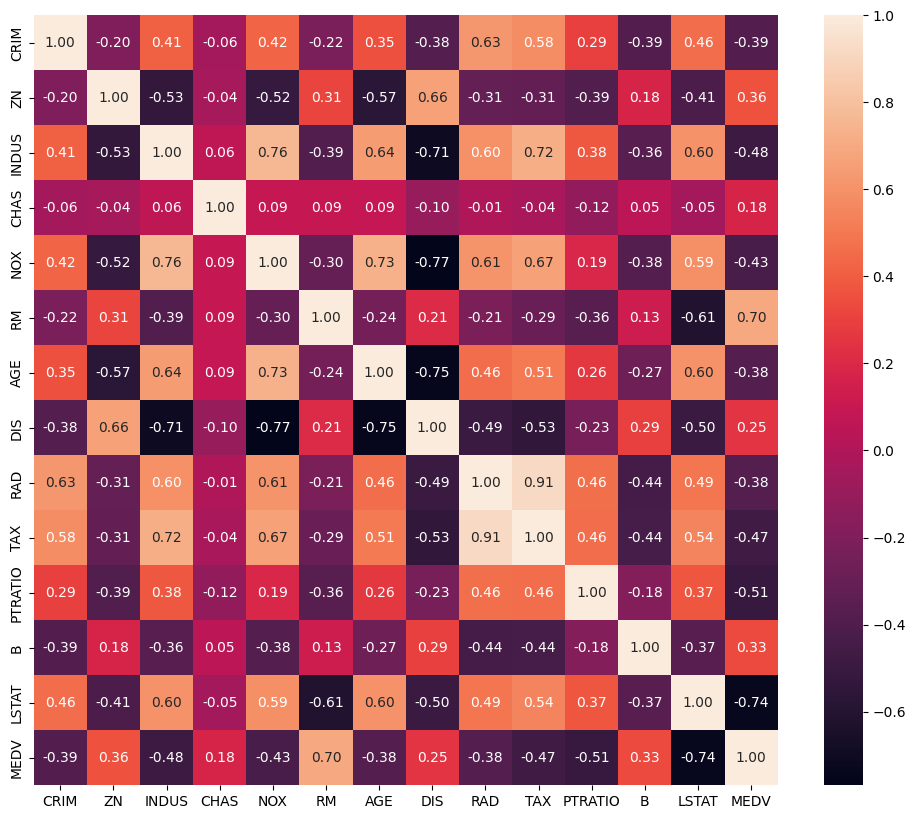

In [121]:
#тепловая карта
plt.figure(figsize = (12,10))
sns.heatmap(df_corr, annot = True, fmt = ".2f")

In [122]:
# отбор признаков
corr_lst = df_corr["MEDV"].abs().sort_values(ascending=False) 
corr_lst

MEDV       1.000000
LSTAT      0.737663
RM         0.695360
PTRATIO    0.507787
INDUS      0.483725
TAX        0.468536
NOX        0.427321
CRIM       0.388305
RAD        0.381626
AGE        0.376955
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
Name: MEDV, dtype: float64

In [123]:
#выбираем признаки, у которых корреляция больше 0.4
selected_features = corr_lst.index[1:6]
selected_features

Index(['LSTAT', 'RM', 'PTRATIO', 'INDUS', 'TAX'], dtype='str')

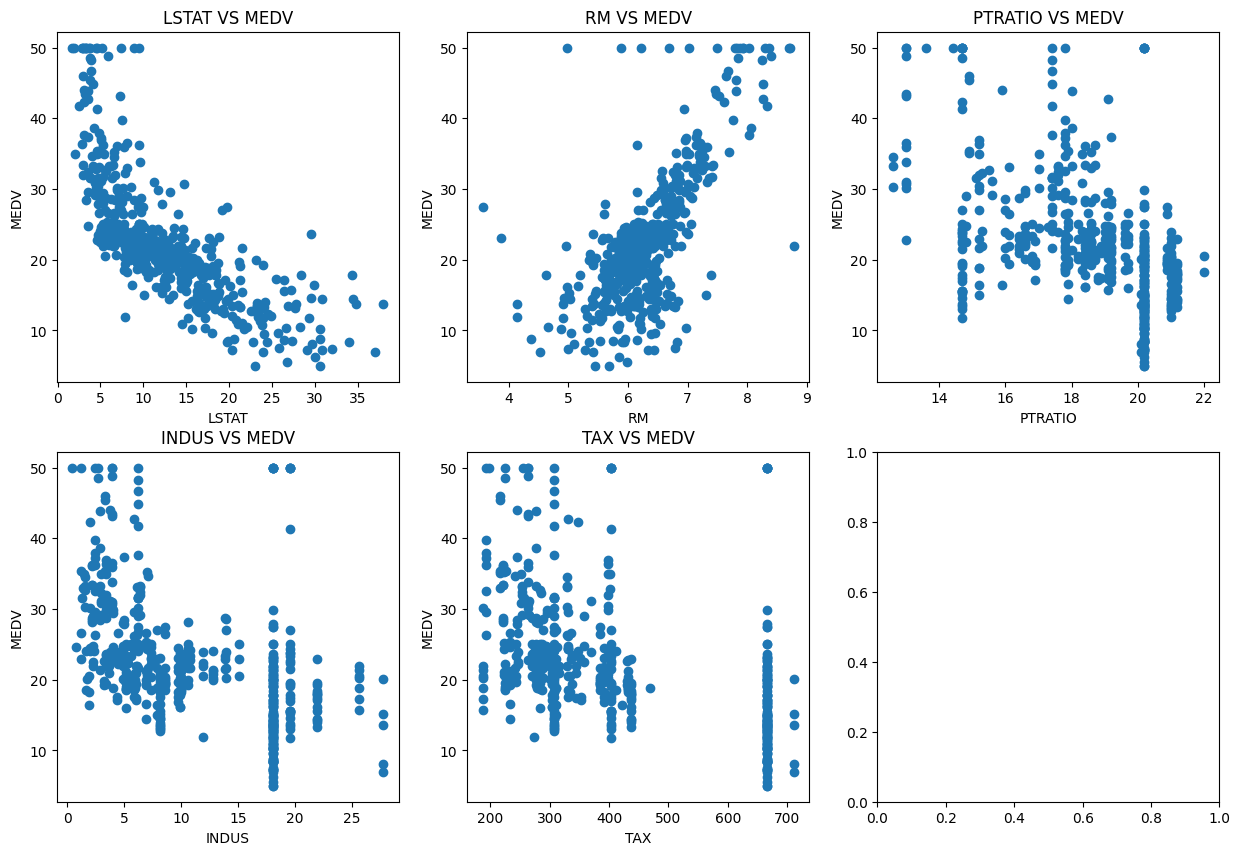

In [124]:
# точечная диаграмма для выбранных признаков и таргета
fig, axes = plt.subplots(2, 3, figsize = (15,10))
axes = axes.flatten()

for i, feature in enumerate(selected_features):
    axes[i].scatter(df[feature], df["MEDV"])
    
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("MEDV")

    axes[i].set_title(f"{feature} VS MEDV")

In [125]:
# разделение признаков и таргета
X = df[selected_features]
y = df["MEDV"]
print(X.shape)
print(y.shape)

(506, 5)
(506,)


<Axes: >

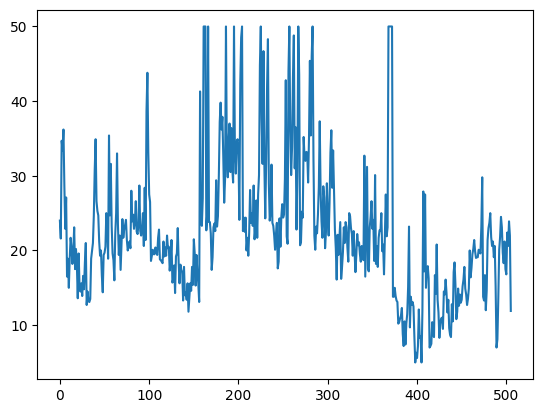

In [126]:
y.plot()

In [127]:
#разбиение на выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(X_train.shape)
print(X_test.shape)

(404, 5)
(102, 5)


In [128]:
#линейная модель
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [129]:
#предсказание
y_train_predict = lr_model.predict(X_train)
y_test_predict = lr_model.predict(X_test)

In [130]:
r2_train = r2_score(y_train, y_train_predict)
r2_test = r2_score(y_test, y_test_predict)
print(f"R^2 train {r2_train:.3f}")
print(f"R^2 test {r2_test:.3f}")

R^2 train 0.690
R^2 test 0.620


In [131]:
rmse_train = root_mean_squared_error (y_train, y_train_predict)
rmse_test = root_mean_squared_error (y_test, y_test_predict)
print(f"Rmse train {rmse_train:.3f}")
print(f"Rmse test {rmse_test:.3f}")

Rmse train 5.187
Rmse test 5.281


## для себя

In [133]:
#попробуем нормализовать данные 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [134]:
#линейная модель
lr_model_scaled = LinearRegression()
lr_model_scaled.fit(X_train_scaled, y_train)
#предсказание
y_train_predict_scaled = lr_model_scaled.predict(X_train_scaled)
y_test_predict_scaled = lr_model_scaled.predict(X_test_scaled)
r2_train_scaled = r2_score(y_train, y_train_predict_scaled)
r2_test_scaled = r2_score(y_test, y_test_predict_scaled)
print(f"R^2 train {r2_train_scaled:.3f}")
print(f"R^2 test {r2_test_scaled:.3f}")
rmse_train_scaled = root_mean_squared_error (y_train, y_train_predict_scaled)
rmse_test_scaled = root_mean_squared_error (y_test, y_test_predict_scaled)
print(f"Rmse train {rmse_train_scaled:.3f}")
print(f"Rmse test {rmse_test_scaled:.3f}")

R^2 train 0.690
R^2 test 0.620
Rmse train 5.187
Rmse test 5.281


## доп

{'whiskers': [<matplotlib.lines.Line2D at 0x237d0065f90>,
 'caps': [<matplotlib.lines.Line2D at 0x237d0066210>,
 'boxes': [<matplotlib.lines.Line2D at 0x237d0065e50>],
 'medians': [<matplotlib.lines.Line2D at 0x237d0066490>],
 'fliers': [<matplotlib.lines.Line2D at 0x237d00665d0>],
 'means': []}

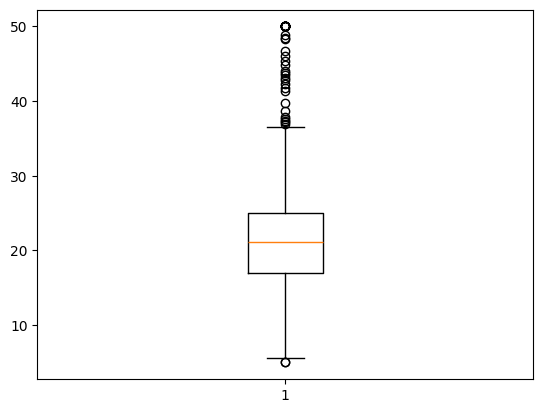

In [ ]:
#строим boxplot
plt.boxplot(df["MEDV"])

In [68]:
#определяем выбросы
q1 = df["MEDV"].quantile(0.25)
q3 = df["MEDV"].quantile(0.75)
iqr = q3 - q1
up = q3 + 1.5 * iqr
low = q1 - 1.5 * iqr
out = df[(df["MEDV"] < low) | (df["MEDV"] > up)]
print(q1, q3)
print(f"Количество выбросов {len(out)}")

17.025 25.0
Количество выбросов 40


In [75]:
#удаляем выбросы
df_clean = df[(df["MEDV"] >= low) & (df["MEDV"] <= up)]
len(df), len(df_clean)

(506, 466)

In [76]:
# разделение признаков и таргета
X_clean = df_clean[selected_features]
y_clean = df_clean["MEDV"]
print(X_clean.shape)
print(y_clean.shape)

(466, 5)
(466,)


<Axes: >

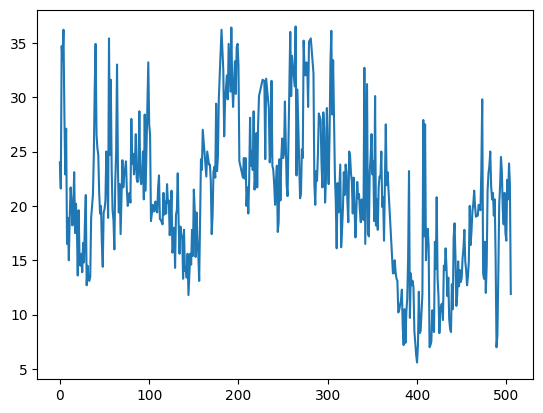

In [77]:
y_clean.plot()

In [78]:
#разбиение на выборки
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(X_clean, y_clean, test_size = 0.2, random_state = 42)
print(X_train.shape)
print(X_test.shape)

(372, 5)
(94, 5)


Linear

In [79]:
#линейная модель
lr_model_clean = LinearRegression()
lr_model_clean.fit(X_train_clean, y_train_clean)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [80]:
#предсказание
y_train_predict_clean = lr_model_clean.predict(X_train_clean)
y_test_predict_clean = lr_model_clean.predict(X_test_clean)

In [ ]:
r2_train_clean = r2_score(y_train_clean, y_train_predict_clean)
r2_test_clean = r2_score(y_test_clean, y_test_predict_clean)
print(f"R^2 train {r2_train_clean:.3f}")
print(f"R^2 test {r2_test_clean:.3f}")
# r^2 - если 1, то модель идельно предсказывает данные. 0 - не лучше среднего 
# это доля дисперсии целевой переменной которую объясняет наша модель 

R^2 train 0.704
R^2 test 0.690


In [ ]:
rmse_train_clean = root_mean_squared_error (y_train_clean, y_train_predict_clean)
rmse_test_clean = root_mean_squared_error (y_test_clean, y_test_predict_clean)
print(f"Rmse train {rmse_train_clean:.3f}")
print(f"Rmse test {rmse_test_clean:.3f}")

Rmse train 3.522
Rmse test 3.527


Ridge

In [93]:
ridge_model = Ridge()
ridge_model.fit(X_train_clean, y_train_clean)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [94]:
#предсказание
y_train_predict_ridge = ridge_model.predict(X_train_clean)
y_test_predict_ridge = ridge_model.predict(X_test_clean)

In [95]:
r2_train_ridge = r2_score(y_train_clean, y_train_predict_ridge)
r2_test_ridge = r2_score(y_test_clean, y_test_predict_ridge)
print(f"R^2 train {r2_train_ridge:.3f}")
print(f"R^2 test {r2_test_ridge:.3f}")

R^2 train 0.704
R^2 test 0.691


In [96]:
rmse_train_ridge = root_mean_squared_error (y_train_clean, y_train_predict_ridge)
rmse_test_ridge = root_mean_squared_error (y_test_clean, y_test_predict_ridge)
print(f"Rmse train {rmse_train_ridge:.3f}")
print(f"Rmse test {rmse_test_ridge:.3f}")

Rmse train 3.522
Rmse test 3.523


<Axes: >

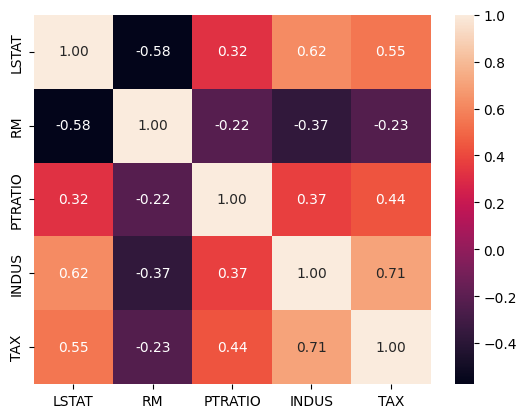

In [110]:
sns.heatmap(df_clean[selected_features].corr(), annot = True, fmt = ".2f")
#между собой признаки мало коррелируют

In [111]:
for alpha in [0.1, 1, 10, 100]:
    rdg = Ridge(alpha = alpha)
    rdg.fit(X_train_clean, y_train_clean)
    prd = rdg.predict(X_test_clean)
    rmse = root_mean_squared_error(y_test_clean, prd)
    print(f"alpha = {alpha}, rmse = {rmse}")

alpha = 0.1, rmse = 3.526502539315941
alpha = 1, rmse = 3.522836601427022
alpha = 10, rmse = 3.4930532277924407
alpha = 100, rmse = 3.421076022153632


Polynomyal

In [102]:
poly = PolynomialFeatures(degree = 3)

In [103]:
X_train_poly = poly.fit_transform(X_train_clean)
X_test_poly = poly.transform(X_test_clean)

In [104]:
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train_clean)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [105]:
#предсказание
y_train_predict_poly = poly_model.predict(X_train_poly)
y_test_predict_poly = poly_model.predict(X_test_poly)

In [106]:
r2_train_poly = r2_score(y_train_clean, y_train_predict_poly)
r2_test_poly = r2_score(y_test_clean, y_test_predict_poly)
print(f"R^2 train {r2_train_poly:.3f}")
print(f"R^2 test {r2_test_poly:.3f}")

R^2 train 0.848
R^2 test 0.743


In [107]:
rmse_train_poly = root_mean_squared_error(y_train_clean, y_train_predict_poly)
rmse_test_poly = root_mean_squared_error(y_test_clean, y_test_predict_poly)
print(f"Rmse train {rmse_train_ridge:.3f}")
print(f"Rmse test {rmse_test_ridge:.3f}")

Rmse train 3.522
Rmse test 3.523


In [109]:
pd.DataFrame({
    'Модель': [
        "Линейная с выбросами",
        "Линейная без выбросов",
        "Ridge",
        "Полиномиальная"
    ],
    "R^2 train": [r2_train, r2_train_clean, r2_train_ridge, r2_train_poly],
    "R^2 test": [r2_test, r2_test_clean, r2_test_ridge, r2_test_poly],
    "RMSE train": [rmse_train, rmse_train_clean, rmse_train_ridge, rmse_train_poly],
    "RMSE test": [rmse_test, rmse_test_clean, rmse_test_ridge, rmse_test_poly],
})

,Модель,R^2 train,R^2 test,RMSE train,RMSE test
0,Линейная с выбросами,0.690258,0.619668,5.187326,5.281208
1,Линейная без выбросов,0.703700,0.689916,3.522346,3.526919
2,Ridge,0.703695,0.690634,3.522377,3.522837
3,Полиномиальная,0.848046,0.742579,2.522449,3.213494
